In [67]:
# Importación de librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [68]:
# Leer el dataset

df = pd.read_csv("data.csv")

In [69]:
# Vista previa

print("Primeras filas:")
display(df.head())

Primeras filas:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [70]:
# Eliminar nulos (o reemplazar)
print("Valores nulos antes:")
print(df.isnull().sum())

Valores nulos antes:
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64


In [71]:
# Estadísticas descriptivas

print("\nEstadísticas descriptivas:")
display(df.describe())


Estadísticas descriptivas:


,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


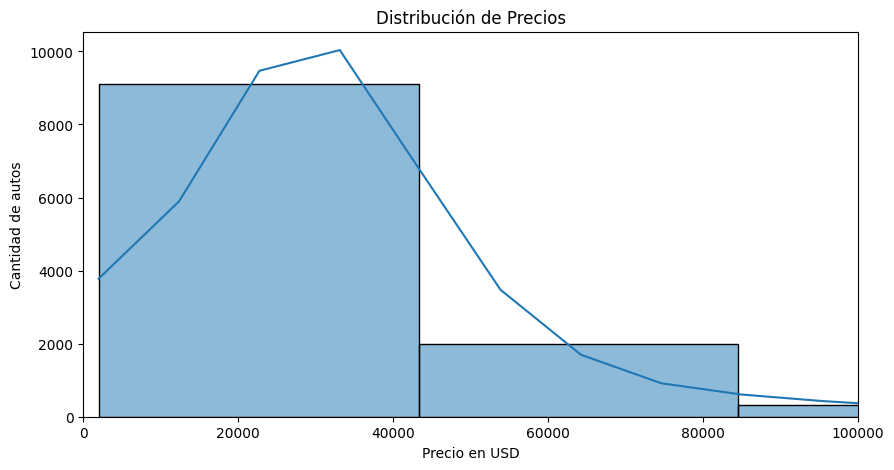

In [72]:
# Histograma de precios

plt.figure(figsize=(10, 5))
sns.histplot(df['MSRP'], bins=50, kde=True)
plt.title('Distribución de Precios')
plt.xlabel('Precio en USD')
plt.ylabel('Cantidad de autos')
plt.xlim([0, 100000])
plt.show()

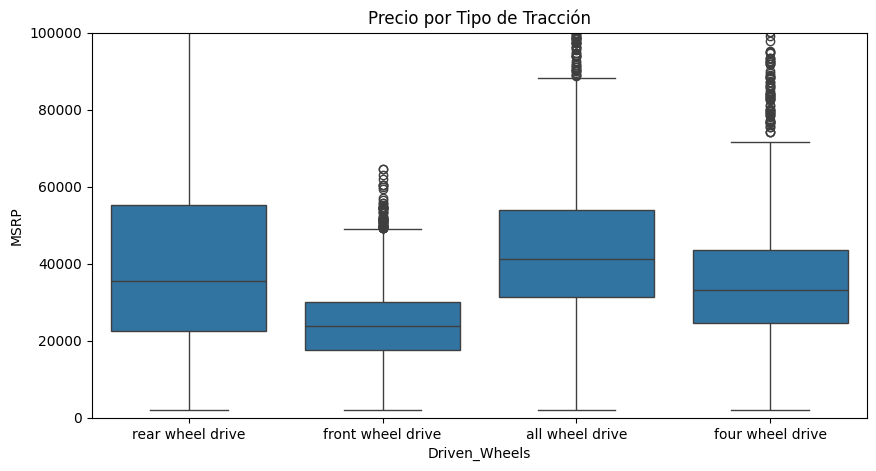

In [73]:
# Boxplot por tipo de tracción

plt.figure(figsize=(10, 5))
sns.boxplot(x='Driven_Wheels', y='MSRP', data=df)
plt.title('Precio por Tipo de Tracción')
plt.ylim([0, 100000])
plt.show()

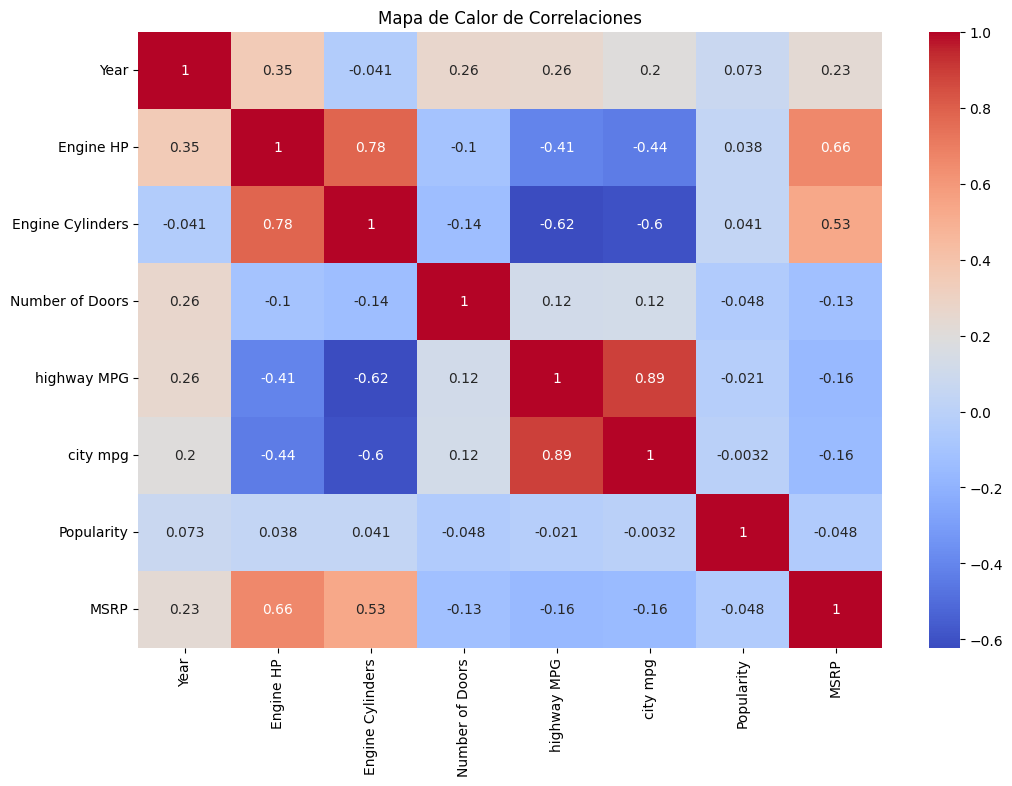

In [74]:
# Mapa de calor de correlaciones numéricas

plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlaciones')
plt.show()

In [75]:
# Rellenar valores nulos

df['Potencia Motor (HP)'] = df['Engine HP'].fillna(df['Engine HP'].mean())
df['Cantidad Cilindros'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].mode()[0])

In [76]:
# Eliminar cualquier fila restante con nulos

df.dropna(inplace=True)
print("\nValores nulos después:")
print(df.isnull().sum())


Valores nulos después:
Make                   0
Model                  0
Year                   0
Engine Fuel Type       0
Engine HP              0
Engine Cylinders       0
Transmission Type      0
Driven_Wheels          0
Number of Doors        0
Market Category        0
Vehicle Size           0
Vehicle Style          0
highway MPG            0
city mpg               0
Popularity             0
MSRP                   0
Potencia Motor (HP)    0
Cantidad Cilindros     0
dtype: int64


In [77]:
# Normalizar la variable 'MSRP' (precio)

normalizador = MinMaxScaler()
df['Precio Normalizado'] = normalizador.fit_transform(df[['MSRP']])

In [78]:
# Crear nueva variable derivada: Potencia por cilindro

df['Potencia por Cilindro'] = df['Potencia Motor (HP)'] / df['Cantidad Cilindros']

In [79]:
# Mostrar vista previa de los cambios

print("\nVista de columnas nuevas:")
display(df[['MSRP', 'Precio Normalizado', 'Potencia por Cilindro']].head())


Vista de columnas nuevas:


,MSRP,Precio Normalizado,Potencia por Cilindro
0,46135,0.021384,55.833333
1,40650,0.018727,50.000000
2,36350,0.016643,50.000000
3,29450,0.013300,38.333333
4,34500,0.015747,38.333333


In [80]:
# Variables predictivas y variable objetivo

variables_entrada = df[['Potencia Motor (HP)', 'Cantidad Cilindros', 'highway MPG', 'city mpg', 'Popularity']]
variable_objetivo = df['MSRP']

In [81]:
# Separar en entrenamiento y test

X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(
    variables_entrada, variable_objetivo, test_size=0.2, random_state=42)

In [82]:
# Crear y entrenar el modelo de regresión lineal

modelo = LinearRegression()
modelo.fit(X_entrenamiento, y_entrenamiento)

LinearRegression()

In [83]:
# Predicciones

y_pred = modelo.predict(X_test)

In [84]:
# 📊 Evaluación del modelo
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [85]:
print(f"R² (coeficiente de determinación): {r2:.4f}")
print(f"MAE (error absoluto medio): {mae:.2f} USD")
print(f"RMSE (raíz del error cuadrático medio): {rmse:.2f} USD")

R² (coeficiente de determinación): 0.5238
MAE (error absoluto medio): 24184.00 USD
RMSE (raíz del error cuadrático medio): 46401.56 USD
